# Wolfram Language tour

A short notebook demo of the Wolfram Engine as a CAS for this repo. Covers:

1. Symbolic integration and typeset output
2. LaTeX export for the paper
3. `DSolve` and plotting
4. Symbolic Weber-potential derivation (relevant to `src/weber_system.jl`)

Run top-to-bottom. Outputs render inline as typeset math when the kernel is `wolframlanguage14.3`.

## 1. Symbolic computation

Integrals, closed-form sums, and high-precision numerics.

In [1]:
$Version

14.3.0 for Mac OS X ARM (64-bit) (July 31, 2025)

x   Sin[2 x]
- - --------
2      4
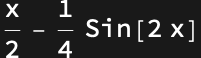

In [2]:
intSin2 = Integrate[Sin[x]^2, x]

FormBox[RowBox[{FractionBox["x", "2"], "-", 

 
>        RowBox[{FractionBox["1", "4"], " ", 

 
>          RowBox[{"sin", "(", RowBox[{"2", " ", "x"}], ")"}]}]}], TraditionalForm]
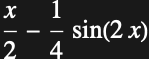

In [4]:
(* Rendered in 2-D typeset form. *)
TraditionalForm[intSin2]

In [6]:
(* Same result as a LaTeX string -- paste into the paper. *)
TeXForm[intSin2]

\frac{x}{2}-\frac{1}{4} \sin (2 x)

FormBox[RowBox[{FractionBox["1", "6"], " ", "n", " ", 

 
>        RowBox[{"(", RowBox[{"n", "+", "1"}], ")"}], " ", 

 
>        RowBox[{"(", RowBox[{RowBox[{"2", " ", "n"}], "+", "1"}], ")"}]}],\
 
>    TraditionalForm]

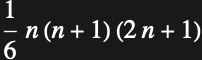

In [9]:
(* Closed-form sum. *)
sumK2 = Sum[k^2, {k, 1, n}];
TraditionalForm[sumK2]

In [11]:
(* High-precision numerics. *)
N[Pi, 50]

3.1415926535897932384626433832795028841971693993751

## 2. Simple harmonic oscillator ODE

Cos[t]
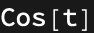

In [13]:
shoSol = DSolve[{y''[t] + y[t] == 0, y[0] == 1, y'[0] == 0}, y[t], t];
yOfT = y[t] /. First[shoSol]

Legended[-Graphics-, Placed[LineLegend[{Directive[Opacity[1.], RGBColor[0.24, 0.6, 0.8], 
 
>       AbsoluteThickness[2]], Directive[Opacity[1.], RGBColor[0.95, 0.627, 0.1425], 
 
>       AbsoluteThickness[2]]}, {y(t), y'(t)}, LegendMarkers -> None, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
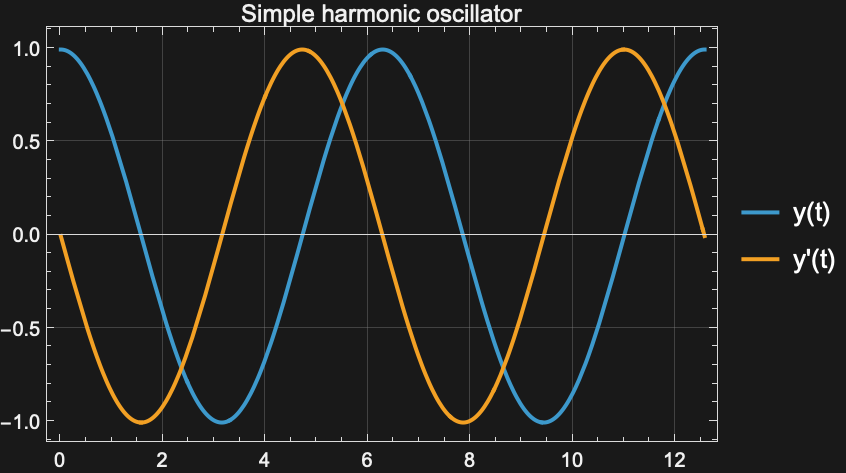

In [15]:
dyOfT = D[yOfT, t];
Plot[{yOfT, dyOfT}, {t, 0, 4 Pi},
  PlotLegends -> {"y(t)", "y'(t)"},
  PlotLabel -> "Simple harmonic oscillator",
  Frame -> True, GridLines -> Automatic]

## 3. Linear algebra

FormBox[RowBox[{"(", "⁠", GridBox[{{RowBox[{"2", "+", SqrtBox["2"]}], "2", 

 
>           RowBox[{"2", "-", SqrtBox["2"]}]}, 

 
>          {RowBox[{"{", RowBox[{"1", ",", SqrtBox["2"], ",", "1"}], "}"}], 

 
>           RowBox[{"{", RowBox[{RowBox[{"-", "1"}], ",", "0", ",", "1"}], "}"}], 

 
>           RowBox[{"{", RowBox[{"1", ",", RowBox[{"-", SqrtBox["2"]}], ",", "1"}], 

 
>             "}"}]}}, Rule[RowSpacings, 1], Rule[ColumnSpacings, 1], 

 
>         Rule[RowAlignments, Baseline], Rule[ColumnAlignments, Center]], "⁠", ")"}], 

 
>      TraditionalForm]
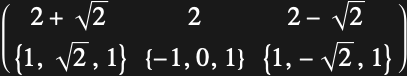

In [18]:
M = {{2, 1, 0}, {1, 2, 1}, {0, 1, 2}};
{eigvals, eigvecs} = Eigensystem[M];
TraditionalForm[{eigvals, eigvecs}]

## 4. Weber pair potential (repo-relevant)

The Weber two-body potential is

$$U_W(r, \dot r) = \frac{q_1 q_2}{r}\left(1 - \frac{\dot r^2}{2 c^2}\right).$$

For a central two-body problem in the plane with angular momentum $\ell$ and reduced mass $\mu$, the effective radial equation involves $\partial U_W/\partial r$ and a $\dot r$-dependent term. Here we compute both symbolically.

FormBox[FractionBox[RowBox[{"q1", " ", "q2", " ", 

 
>         RowBox[{"(", RowBox[{"1", "-", 

 
>             FractionBox[SuperscriptBox["rDot", "2"], 

 
>              RowBox[{"2", " ", SuperscriptBox["c", "2"]}]]}], ")"}]}], "r"], 

 
>      TraditionalForm]
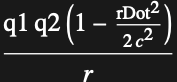

In [21]:
ClearAll[r, rDot, q1, q2, c];
UW = (q1 q2 / r) (1 - rDot^2 / (2 c^2));
TraditionalForm[UW]

FormBox[RowBox[{"-", FractionBox[RowBox[{"q1", " ", "q2", " ", 

 
>           RowBox[{"(", RowBox[{"1", "-", 

 
>               FractionBox[SuperscriptBox["rDot", "2"], 

 
>                RowBox[{"2", " ", SuperscriptBox["c", "2"]}]]}], ")"}]}], 

 
>         SuperscriptBox["r", "2"]]}], TraditionalForm]
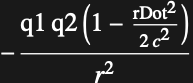

In [23]:
dUdr = D[UW, r] // Simplify;
TraditionalForm[dUdr]

FormBox[RowBox[{"-", FractionBox[RowBox[{"q1", " ", "q2", " ", "rDot"}], 

 
>         RowBox[{SuperscriptBox["c", "2"], " ", "r"}]]}], TraditionalForm]
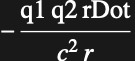

In [25]:
dUdrDot = D[UW, rDot] // Simplify;
TraditionalForm[dUdrDot]

U_W            = \frac{\text{q1} \text{q2} \left(1-\frac{\text{rDot}^2}{2 c^2}\right)}{r}
dU_W/dr        = -\frac{\text{q1} \text{q2} \left(1-\frac{\text{rDot}^2}{2\
 
>    c^2}\right)}{r^2}
dU_W/d(rDot)   = -\frac{\text{q1} \text{q2} \text{rDot}}{c^2 r}
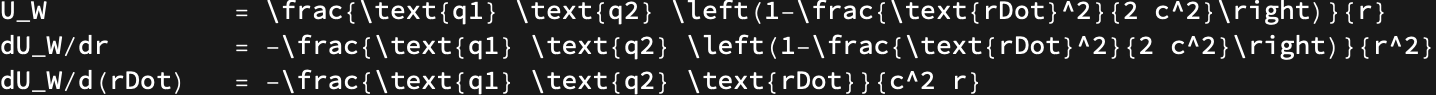

In [27]:
(* LaTeX for the paper. *)
Column[{
  Row[{"U_W            = ", TeXForm[UW]}],
  Row[{"dU_W/dr        = ", TeXForm[dUdr]}],
  Row[{"dU_W/d(rDot)   = ", TeXForm[dUdrDot]}]
}]

## 5. Numeric exploration

Sample trajectory of the SHO on a grid. `ListPlot` renders inline.

-Graphics-
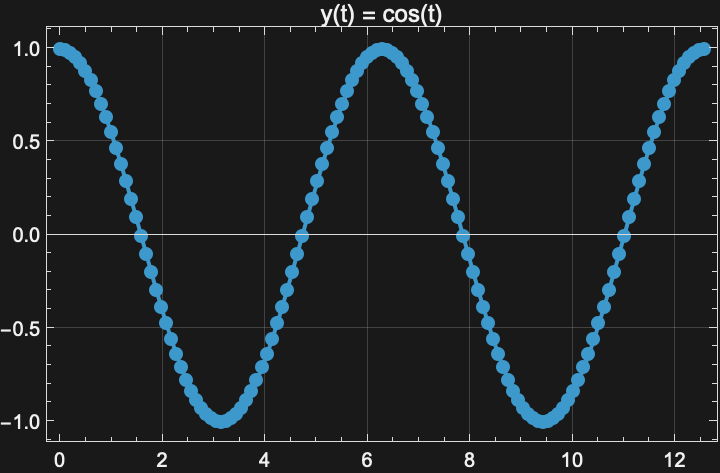

In [30]:
ts = Range[0, 4 Pi, Pi/32];
pts = Transpose[{ts, Cos[ts]}];
ListPlot[pts, Joined -> True, PlotMarkers -> Automatic,
  Frame -> True, GridLines -> Automatic, PlotLabel -> "y(t) = cos(t)"]

## 6. Exporting to the paper

Any symbolic result can be written to disk as:

1. A LaTeX snippet (`snippets.tex`) to `\input{}` into the paper.
2. A publication plot (`sho_plot.png`).
3. A rasterized 2-D typeset expression (`integral_typeset.png`) for slides or figures.

All outputs land in `wolfram/out/` (gitignored).

In [34]:
(* 1. Set up an output directory next to this notebook.
   In both Jupyter Lab / VS Code and headless `nbconvert` runs, the
   kernel's working directory is the notebook's directory. *)
outDir = FileNameJoin[{Directory[], "out"}];
If[! DirectoryQ[outDir], CreateDirectory[outDir]];
outDir

/Users/mac/dev/Weber/WeberElectrodynamics/wolfram/out

In [39]:
(* 2. Write a multi-line align snippet ready for \input{} in the paper. *)
texFile = FileNameJoin[{outDir, "snippets.tex"}];
texBody = StringJoin[
  "% Auto-generated by wolfram/tour.ipynb -- do not edit by hand.\n",
  "\\begin{align}\n",
  "  \\int \\sin^2 x\\,dx &= ", ToString[TeXForm[intSin2]],    " \\\\\n",
  "  \\sum_{k=1}^{n} k^2 &= ", ToString[TeXForm[sumK2]],        " \\\\\n",
  "  y(t) &= ",                ToString[TeXForm[yOfT]],         " \\\\\n",
  "  \\frac{\\partial U_W}{\\partial r} &= ",
     ToString[TeXForm[dUdr]], "\n",
  "\\end{align}\n"
];
Export[texFile, texBody, "Text"];
texFile

/Users/mac/dev/Weber/WeberElectrodynamics/wolfram/out/snippets.tex

In [44]:
(* 3. Publication plot to PNG. *)
pltFile = FileNameJoin[{outDir, "sho_plot.png"}];
plt = Plot[{yOfT, dyOfT}, {t, 0, 4 Pi},
  PlotLegends -> {"y(t)", "y'(t)"},
  PlotLabel -> "Simple harmonic oscillator",
  Frame -> True, GridLines -> Automatic, ImageSize -> 600];
Export[pltFile, plt, "PNG", ImageResolution -> 200];
pltFile

/Users/mac/dev/Weber/WeberElectrodynamics/wolfram/out/sho_plot.png

In [49]:
(* 4. Rasterize 2-D typeset math to PNG -- headless, no front end needed. *)
imgFile = FileNameJoin[{outDir, "integral_typeset.png"}];
img = Rasterize[
  TraditionalForm[HoldForm[Integrate[Sin[x]^2, x]] == intSin2],
  "Image", ImageResolution -> 240
];
Export[imgFile, img, "PNG"];
imgFile

/Users/mac/dev/Weber/WeberElectrodynamics/wolfram/out/integral_typeset.png

## Next steps

- Use `TeXForm[expr]` to copy symbolic results straight into `papers/Computational-Weber-Electrodynamics/`.
- The same `wolframlanguage14.3` kernel works in both Jupyter Lab and the VS Code Wolfram Language extension — pick your editor.
- `Manipulate[...]` and `Dynamic[...]` work in Jupyter output cells too (try `Manipulate[Plot[Sin[a x], {x, 0, 2 Pi}], {a, 1, 5}]`).